#### Importo librerías y cargo el dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

nba = pd.read_csv('nba.csv')

#### Empiezo a mirar la información y los datos del dataset

In [2]:
nba.info()

<class 'pandas.DataFrame'>
RangeIndex: 12844 entries, 0 to 12843
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         12844 non-null  int64  
 1   player_name        12844 non-null  str    
 2   team_abbreviation  12844 non-null  str    
 3   age                12844 non-null  float64
 4   player_height      12844 non-null  float64
 5   player_weight      12844 non-null  float64
 6   college            10990 non-null  str    
 7   country            12844 non-null  str    
 8   draft_year         12844 non-null  str    
 9   draft_round        12844 non-null  str    
 10  draft_number       12844 non-null  str    
 11  gp                 12844 non-null  int64  
 12  pts                12844 non-null  float64
 13  reb                12844 non-null  float64
 14  ast                12844 non-null  float64
 15  net_rating         12844 non-null  float64
 16  oreb_pct           12844 non-null

#### Los significados de las columnas son:
* player_name: nombre del jugador
* team_abbreviation: abreviatura del equipo
* age: edad
* player_height: altura
* player_weight: peso en kg
* college: universidad de origen
* country: país de origen
* draft_year: año del draft
* draft_round: ronda del draft (1 o 2)
* draft_number: pick exacto del draft
* gp: partidos jugados
* pts:	puntos por partido (variable objetivo)
* reb: rebotes por partido
* ast: asistencias por partido
* net_rating: diferencial de puntos por 100 posesiones con el jugador en pista
* usg_pct:	% de posesiones que usa el jugador cuando está en pista
* ts_pct: eficiencia de tiro (2s, 3s y tiros libres combinados)
* ast_pct:	% de canastas de compañeros que asiste
* oreb_pct:	% de rebotes ofensivos disponibles que captura
* dreb_pct:	% de rebotes defensivos disponibles que captura
* season: temporada (ej. 2022-23)

In [3]:
nba.head(10)

,Unnamed: 0,player_name,team_abbreviation,age,player_height,player_weight,college,country,draft_year,draft_round,...,pts,reb,ast,net_rating,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct,season
0,0,Randy Livingston,HOU,22.0,193.04,94.800728,Louisiana State,USA,1996,2,...,3.9,1.5,2.4,0.3,0.042,0.071,0.169,0.487,0.248,1996-97
1,1,Gaylon Nickerson,WAS,28.0,190.50,86.182480,Northwestern Oklahoma,USA,1994,2,...,3.8,1.3,0.3,8.9,0.030,0.111,0.174,0.497,0.043,1996-97
2,2,George Lynch,VAN,26.0,203.20,103.418976,North Carolina,USA,1993,1,...,8.3,6.4,1.9,-8.2,0.106,0.185,0.175,0.512,0.125,1996-97
3,3,George McCloud,LAL,30.0,203.20,102.058200,Florida State,USA,1989,1,...,10.2,2.8,1.7,-2.7,0.027,0.111,0.206,0.527,0.125,1996-97
4,4,George Zidek,DEN,23.0,213.36,119.748288,UCLA,USA,1995,1,...,2.8,1.7,0.3,-14.1,0.102,0.169,0.195,0.500,0.064,1996-97
5,5,Gerald Wilkins,ORL,33.0,198.12,102.058200,Tennessee-Chattanooga,USA,1985,2,...,10.6,2.2,2.2,-5.8,0.031,0.064,0.203,0.503,0.143,1996-97
6,6,Gheorghe Muresan,WAS,26.0,231.14,137.438376,NaN,USA,1993,2,...,10.6,6.6,0.4,6.9,0.098,0.217,0.185,0.618,0.024,1996-97
7,7,Glen Rice,CHH,30.0,203.20,99.790240,Michigan,USA,1989,1,...,26.8,4.0,2.0,3.2,0.025,0.087,0.272,0.605,0.088,1996-97
8,8,Glenn Robinson,MIL,24.0,200.66,106.594120,Purdue,USA,1994,1,...,21.1,6.3,3.1,-2.9,0.051,0.144,0.278,0.528,0.146,1996-97
9,9,Grant Hill,DET,24.0,203.20,102.058200,Duke,USA,1994,1,...,21.4,9.0,7.3,6.9,0.049,0.232,0.283,0.556,0.356,1996-97


#### A simple vista, la columna unnamed no tiene sentido. Para predecir los puntos de un jugador, el equipo, la universidad, todo lo que tiene que ver con el draft altura y peso, rebotes y asistencias, no tiene importancia. De momento, quitaré columnas y luego hago pairplot y heatmap.

In [4]:
# quito columnas
nba_ml = nba.drop(columns=['Unnamed: 0', 'college', 'draft_year', 'draft_round', 'draft_number', 'season'])
nba_ml

,player_name,team_abbreviation,age,player_height,player_weight,country,gp,pts,reb,ast,net_rating,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct
0,Randy Livingston,HOU,22.0,193.04,94.800728,USA,64,3.9,1.5,2.4,0.3,0.042,0.071,0.169,0.487,0.248
1,Gaylon Nickerson,WAS,28.0,190.50,86.182480,USA,4,3.8,1.3,0.3,8.9,0.030,0.111,0.174,0.497,0.043
2,George Lynch,VAN,26.0,203.20,103.418976,USA,41,8.3,6.4,1.9,-8.2,0.106,0.185,0.175,0.512,0.125
3,George McCloud,LAL,30.0,203.20,102.058200,USA,64,10.2,2.8,1.7,-2.7,0.027,0.111,0.206,0.527,0.125
4,George Zidek,DEN,23.0,213.36,119.748288,USA,52,2.8,1.7,0.3,-14.1,0.102,0.169,0.195,0.500,0.064
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12839,Joel Embiid,PHI,29.0,213.36,127.005760,Cameroon,66,33.1,10.2,4.2,8.8,0.057,0.243,0.370,0.655,0.233
12840,John Butler Jr.,POR,20.0,213.36,86.182480,USA,19,2.4,0.9,0.6,-16.1,0.012,0.065,0.102,0.411,0.066
12841,John Collins,ATL,25.0,205.74,102.511792,USA,71,13.1,6.5,1.2,-0.2,0.035,0.180,0.168,0.593,0.052
12842,Jericho Sims,NYK,24.0,208.28,113.398000,USA,52,3.4,4.7,0.5,-6.7,0.117,0.175,0.074,0.780,0.044


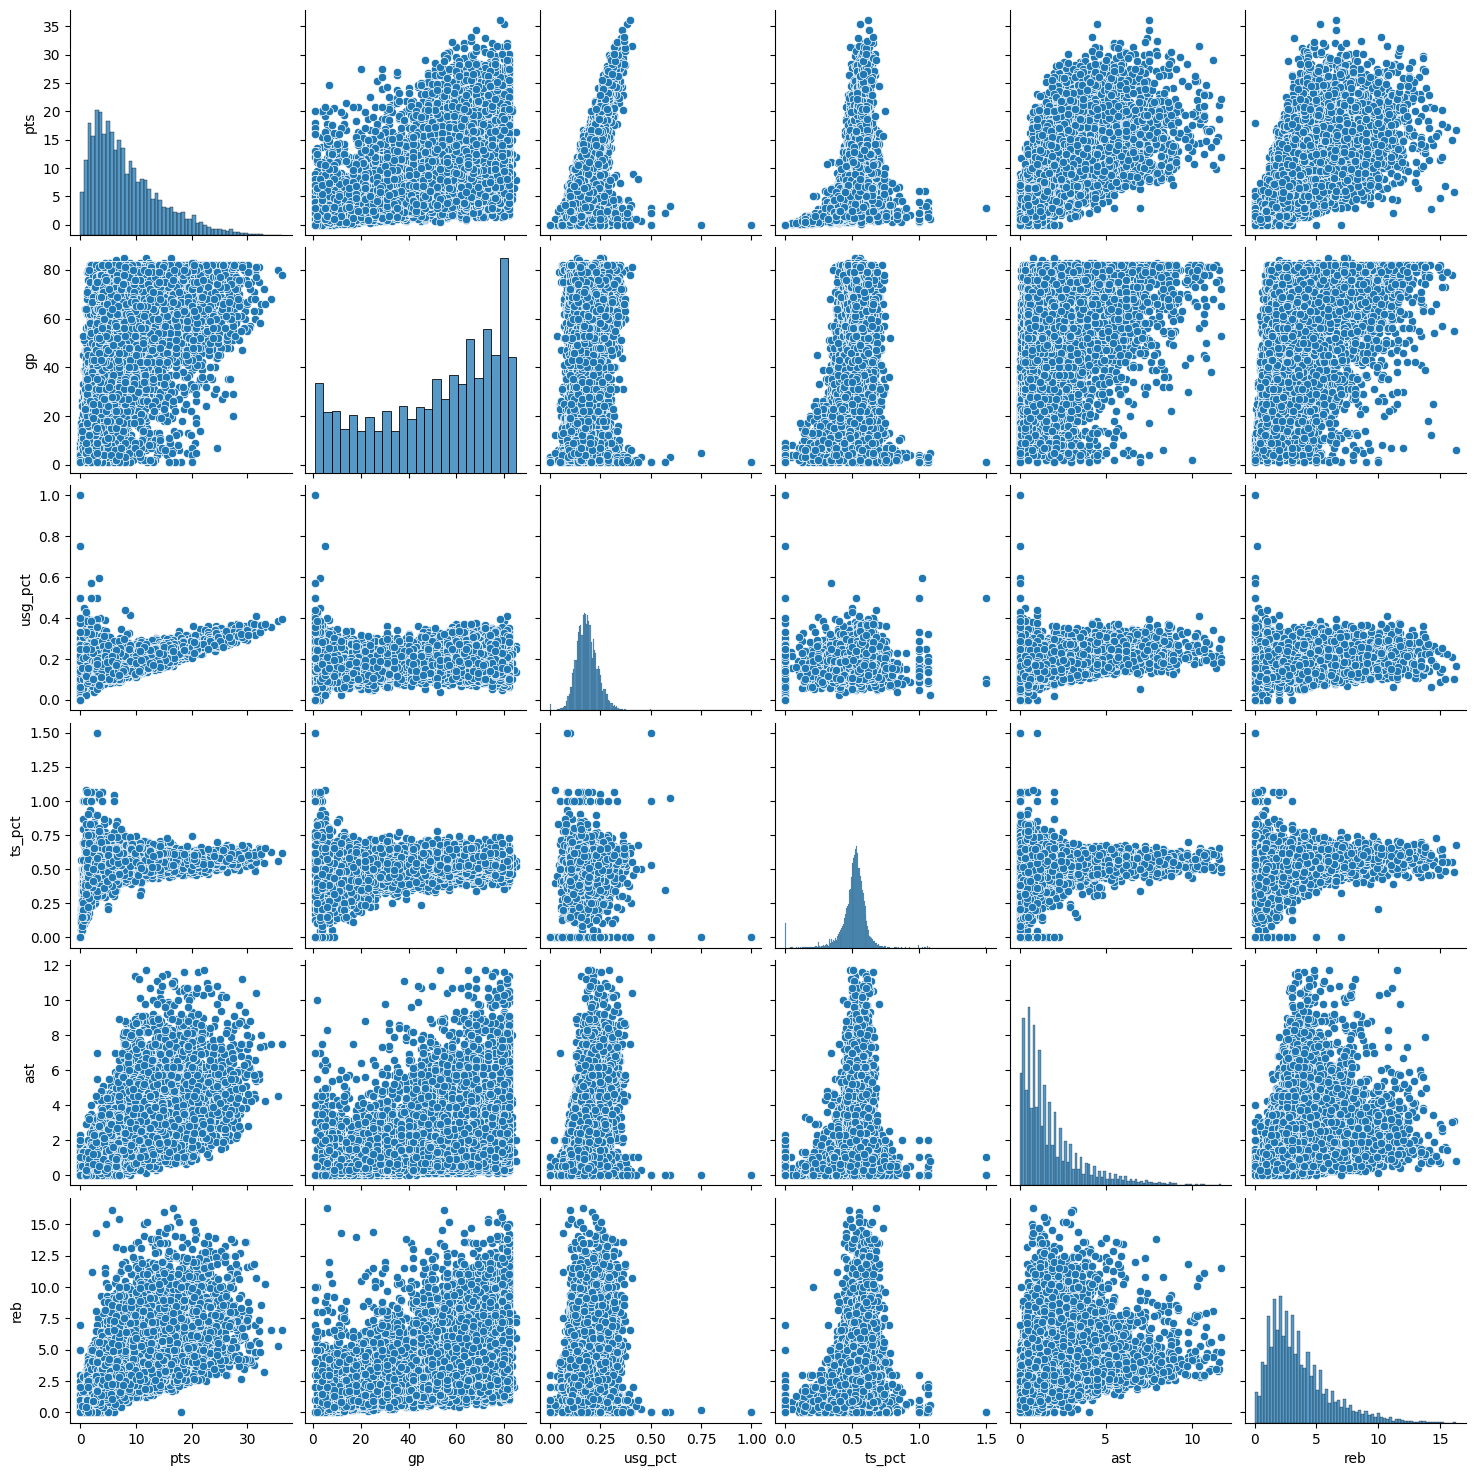

In [5]:
cols = ['pts', 'gp', 'usg_pct', 'ts_pct', 'ast', 'reb']
sns.pairplot(nba_ml[cols]);

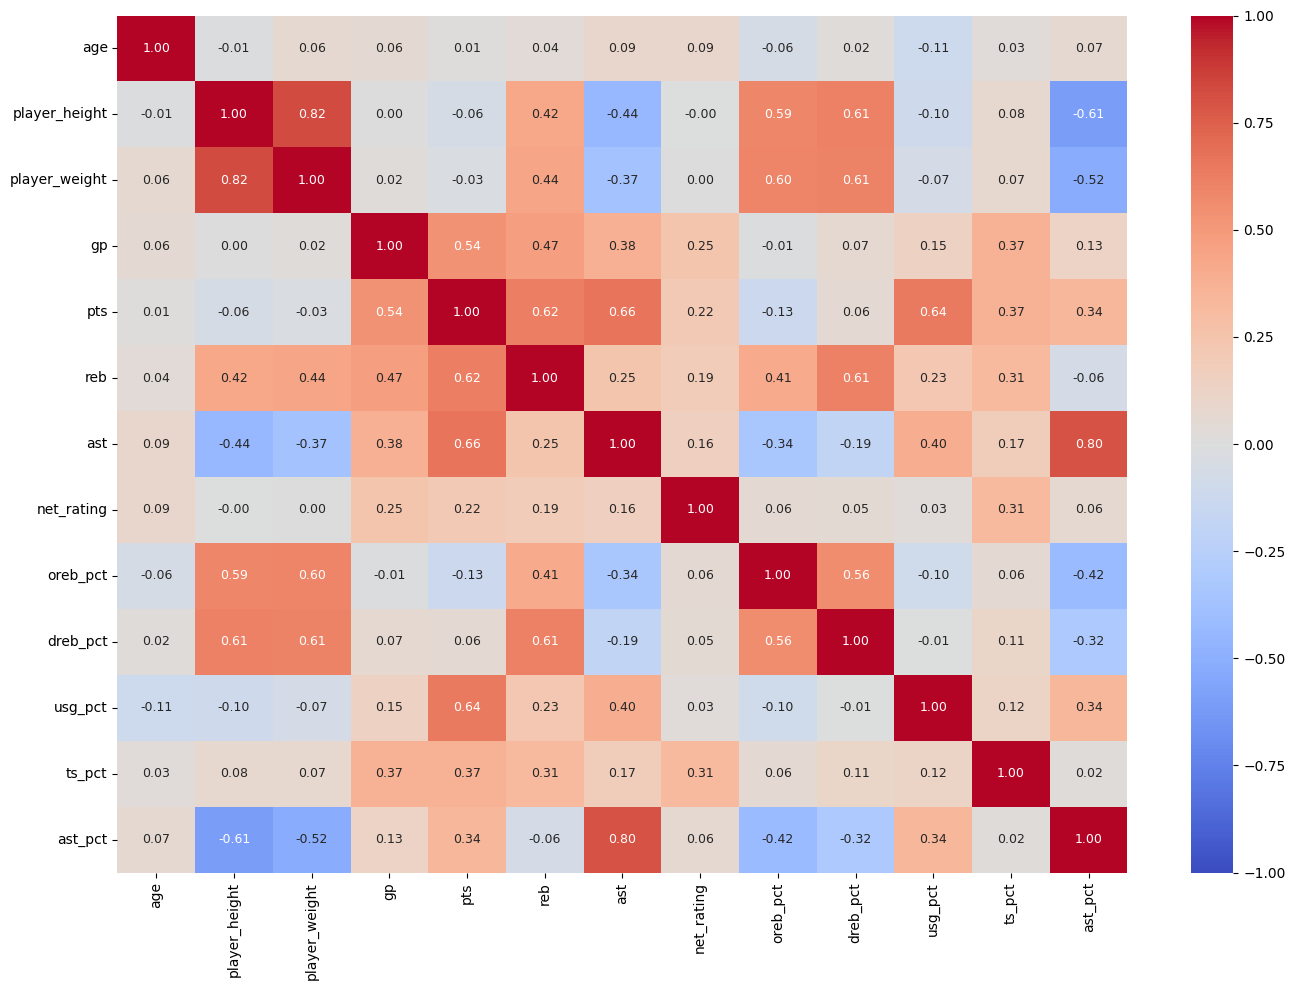

In [6]:
plt.figure(figsize=(14, 10))
sns.heatmap(nba_ml.corr(numeric_only=True), annot=True, cmap='coolwarm', vmin=-1, fmt='.2f', annot_kws={"size": 9})
plt.tight_layout();

#### Se plantea un problema: hay un registro por jugador y año, con lo que me planteo agrupar todos los años de los jugadores, eliminar pts y crear dos nuevas columnas: pts_media_carrera y pts_22_23. Así tengo esa ultima columna como target.

In [16]:
# agrupo por jugador y calculo la media de las estadísticas
nba_agrupado = nba[nba['season'] != '2022-23'].groupby('player_name').mean(numeric_only=True).reset_index()
nba_agrupado.head()

,player_name,Unnamed: 0,age,player_height,player_weight,gp,pts,reb,ast,net_rating,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct
0,A.C. Green,1137.800000,35.0,205.74,102.058200,75.800000,5.78,6.060000,0.860000,-1.880000,0.093000,0.186400,0.127400,0.4868,0.054000
1,A.J. Bramlett,1625.000000,23.0,208.28,102.965384,8.000000,1.00,2.800000,0.000000,-32.600000,0.158000,0.208000,0.146000,0.1900,0.000000
2,A.J. Guyton,2504.000000,24.0,185.42,81.646560,26.666667,3.80,0.700000,1.566667,-6.700000,0.013333,0.040000,0.224000,0.3240,0.282000
3,AJ Hammons,9405.000000,24.0,213.36,117.933920,22.000000,2.20,1.600000,0.200000,-0.600000,0.049000,0.199000,0.167000,0.4720,0.038000
4,AJ Price,7153.833333,25.5,187.96,84.821704,43.500000,5.35,1.333333,2.000000,-2.233333,0.017667,0.090833,0.210667,0.4765,0.248833


In [17]:
nba_agrupado.info()

<class 'pandas.DataFrame'>
RangeIndex: 2463 entries, 0 to 2462
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   player_name    2463 non-null   str    
 1   Unnamed: 0     2463 non-null   float64
 2   age            2463 non-null   float64
 3   player_height  2463 non-null   float64
 4   player_weight  2463 non-null   float64
 5   gp             2463 non-null   float64
 6   pts            2463 non-null   float64
 7   reb            2463 non-null   float64
 8   ast            2463 non-null   float64
 9   net_rating     2463 non-null   float64
 10  oreb_pct       2463 non-null   float64
 11  dreb_pct       2463 non-null   float64
 12  usg_pct        2463 non-null   float64
 13  ts_pct         2463 non-null   float64
 14  ast_pct        2463 non-null   float64
dtypes: float64(14), str(1)
memory usage: 288.8 KB


In [18]:
# añado la media de puntos de la temporada 2022-23 como columna target
pts_22_23 = nba[nba['season'] == '2022-23'][['player_name', 'pts']].rename(columns={'pts': 'pts_22_23'})
# hago un merge para añadir la columna pts_22_23 al dataframe agrupado
nba_agrupado = nba_agrupado.merge(pts_22_23, on='player_name', how='left')
nba_agrupado.head()

,player_name,Unnamed: 0,age,player_height,player_weight,gp,pts,reb,ast,net_rating,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct,pts_22_23
0,A.C. Green,1137.800000,35.0,205.74,102.058200,75.800000,5.78,6.060000,0.860000,-1.880000,0.093000,0.186400,0.127400,0.4868,0.054000,NaN
1,A.J. Bramlett,1625.000000,23.0,208.28,102.965384,8.000000,1.00,2.800000,0.000000,-32.600000,0.158000,0.208000,0.146000,0.1900,0.000000,NaN
2,A.J. Guyton,2504.000000,24.0,185.42,81.646560,26.666667,3.80,0.700000,1.566667,-6.700000,0.013333,0.040000,0.224000,0.3240,0.282000,NaN
3,AJ Hammons,9405.000000,24.0,213.36,117.933920,22.000000,2.20,1.600000,0.200000,-0.600000,0.049000,0.199000,0.167000,0.4720,0.038000,NaN
4,AJ Price,7153.833333,25.5,187.96,84.821704,43.500000,5.35,1.333333,2.000000,-2.233333,0.017667,0.090833,0.210667,0.4765,0.248833,NaN


In [19]:
# elimino filas con valores nulos en la columna target
nba_agrupado = nba_agrupado.dropna(subset=['pts_22_23'])
print(nba_agrupado.shape)

(451, 16)


In [20]:
# renombro la columna pts a pts_media_carrera para que quede más claro que es la media de puntos por carrera
nba_agrupado = nba_agrupado.rename(columns={'pts': 'pts_media_carrera'})

In [21]:
nba_agrupado.info()

<class 'pandas.DataFrame'>
Index: 451 entries, 6 to 2458
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   player_name        451 non-null    str    
 1   Unnamed: 0         451 non-null    float64
 2   age                451 non-null    float64
 3   player_height      451 non-null    float64
 4   player_weight      451 non-null    float64
 5   gp                 451 non-null    float64
 6   pts_media_carrera  451 non-null    float64
 7   reb                451 non-null    float64
 8   ast                451 non-null    float64
 9   net_rating         451 non-null    float64
 10  oreb_pct           451 non-null    float64
 11  dreb_pct           451 non-null    float64
 12  usg_pct            451 non-null    float64
 13  ts_pct             451 non-null    float64
 14  ast_pct            451 non-null    float64
 15  pts_22_23          451 non-null    float64
dtypes: float64(15), str(1)
memory usage: 59.9

In [22]:
nba_agrupado.head(10)

,player_name,Unnamed: 0,age,player_height,player_weight,gp,pts_media_carrera,reb,ast,net_rating,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct,pts_22_23
6,Aaron Gordon,10101.750000,22.5,204.787500,102.341695,66.000000,12.812500,6.225000,2.450000,-0.387500,0.057500,0.167250,0.197625,0.540125,0.122500,16.3
10,Aaron Holiday,11102.250000,23.5,183.515000,83.914520,61.250000,7.225000,1.725000,2.350000,1.900000,0.014000,0.079250,0.189750,0.521500,0.182500,3.9
14,Aaron Nesmith,11648.500000,21.5,195.580000,97.522280,49.000000,4.250000,2.250000,0.450000,1.250000,0.033000,0.131500,0.148500,0.540000,0.052000,10.1
15,Aaron Wiggins,11959.000000,23.0,193.040000,86.182480,50.000000,8.300000,3.600000,1.400000,-8.100000,0.040000,0.098000,0.149000,0.556000,0.083000,6.8
25,Admiral Schofield,11404.500000,24.0,195.580000,109.315672,35.500000,3.400000,1.850000,0.600000,-10.300000,0.025000,0.126000,0.130500,0.520000,0.070500,4.2
34,Al Horford,8462.600000,29.0,207.772000,111.281237,63.333333,13.780000,8.026667,3.253333,3.753333,0.069667,0.202867,0.193000,0.568467,0.162067,9.8
42,Alec Burks,9411.727273,25.0,198.120000,95.831619,56.818182,10.727273,3.536364,1.981818,-2.390909,0.028364,0.137273,0.213455,0.530818,0.133818,12.8
48,Aleksej Pokusevski,11338.000000,19.0,213.360000,86.182480,45.000000,8.200000,4.700000,2.200000,-16.700000,0.025000,0.155000,0.197000,0.430000,0.133000,8.1
52,Alex Caruso,10874.600000,26.0,195.072000,84.368112,45.000000,6.420000,2.580000,2.760000,4.660000,0.025800,0.093000,0.144400,0.537600,0.182400,5.6
55,Alex Len,9883.555556,25.0,215.053333,114.909973,63.333333,7.277778,5.577778,0.844444,-5.777778,0.097778,0.205222,0.170556,0.561444,0.068000,1.7


In [23]:
# guardo el dataframe agrupado en un csv
nba_agrupado.to_csv('nba_agrupado.csv', index=False)